<a href="https://colab.research.google.com/github/Anuvarshaj/Amazon/blob/main/Amazon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("asaniczka/amazon-products-dataset-2023-1-4m-products")

print("Path to dataset files:", path)

100%|██████████| 99.2M/99.2M [00:00<00:00, 129MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/asaniczka/amazon-products-dataset-2023-1-4m-products/versions/17


In [2]:
import os
print(os.listdir(path))

['amazon_products.csv', 'amazon_categories.csv']


In [4]:
import pandas as pd
file_path = path + "/amazon_products.csv"
df = pd.read_csv(file_path)
df.head()

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,https://www.amazon.com/dp/B014TMV5YE,4.5,0,139.99,0.00,104,False,2000
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,https://www.amazon.com/dp/B07GDLCQXV,4.5,0,169.99,209.99,104,False,1000
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,https://www.amazon.com/dp/B07XSCCZYG,4.6,0,365.49,429.99,104,False,300
3,B08MVFKGJM,Freeform Hardside Expandable with Double Spinn...,https://m.media-amazon.com/images/I/91k6NYLQyI...,https://www.amazon.com/dp/B08MVFKGJM,4.6,0,291.59,354.37,104,False,400
4,B01DJLKZBA,Winfield 2 Hardside Expandable Luggage with Sp...,https://m.media-amazon.com/images/I/61NJoaZcP9...,https://www.amazon.com/dp/B01DJLKZBA,4.5,0,174.99,309.99,104,False,400


In [37]:
df = pd.read_csv(file_path, nrows=50000)  # load only 50k rows

In [6]:
print(df.columns)

Index(['asin', 'title', 'imgUrl', 'productURL', 'stars', 'reviews', 'price',
       'listPrice', 'category_id', 'isBestSeller', 'boughtInLastMonth'],
      dtype='object')


In [38]:
df = df[['title', 'category_id', 'price', 'stars', 'reviews']].copy()  # Create a copy to avoid SettingWithCopyWarning
df.dropna(inplace=True)

df['price'] = df['price'].astype(float)
df['stars'] = df['stars'].astype(float)

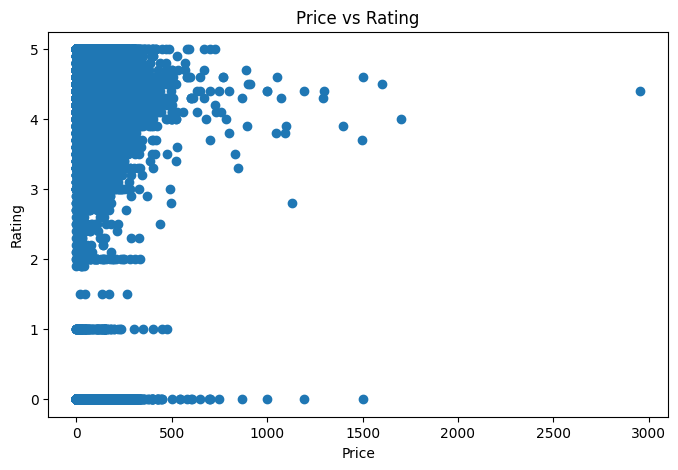

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(df['price'], df['stars'])
plt.xlabel("Price")
plt.ylabel("Rating")
plt.title("Price vs Rating")
plt.show()

In [26]:
print(df['reviews'].head(10))

0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
9    0
Name: reviews, dtype: int64


In [27]:
print(df.columns)

Index(['title', 'category_id', 'price', 'stars', 'reviews', 'sentiment',
       'sentiment_label'],
      dtype='object')


In [29]:
df['sentiment'] = df['reviews'].apply(get_sentiment)

In [39]:
df = df[df['reviews'].notna()]
df['reviews'] = df['reviews'].astype(str)
# Filter out reviews that are just '0', which seem to be placeholders for no reviews
df = df[df['reviews'] != '0']

In [33]:
top_categories = df['category_id'].value_counts().head(10)

In [42]:
top_reviewed = df.sort_values(by='reviews', ascending=False).head(10)

print(top_reviewed[['title', 'reviews']])

                                                   title reviews
47627  Kirby Bags for G4, G5, and Gsix, 197394, 9-Pac...    9993
48124  Filters for Shark Rotator Powered Lift-Away Sp...     999
47403  BLACK+DECKER POWERSERIES+ 20V MAX Cordless Vac...     998
47958  BTRUI for Dyson V8 Battery Adapter for Milwauk...     998
49052  Dttery 3 Pre-Filter Foam & Felt + 1 Hepa, Shar...     998
47623  Lemige 3 Pack Multi-Surface Pet Brush Rolls 27...     994
49603  4 Pieces Vacuum Belts 3031120 Replacement Vacu...     993
49803  2 Pack Replacement Filters for Bissell Power F...     992
49021  Steamfast SF-210 Handheld Steam Cleaner with 6...     991
48074  Eureka Rechargeble Handheld Stick Vac, Powerfu...    9908


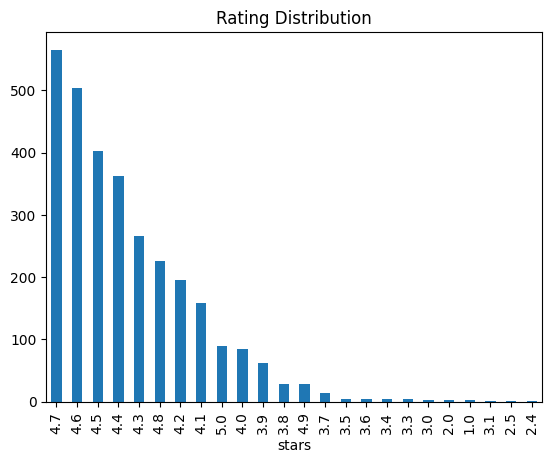

In [44]:
if not df.empty:
    df['stars'].value_counts().plot(kind='bar')
    plt.title("Rating Distribution")
    plt.show()
else:
    print("DataFrame is empty. Cannot plot rating distribution.")
    print("This is likely due to an aggressive filtering operation in a previous cell (e.g., PMFJoXM7P0LW) that removed all rows.")
    print("Consider re-evaluating the filtering conditions or reloading the data to generate the plot.")

In [46]:
import pandas as pd

df = pd.read_csv(file_path, nrows=20000)  # limit rows
print(df.head())

         asin                                              title  \
0  B014TMV5YE  Sion Softside Expandable Roller Luggage, Black...   
1  B07GDLCQXV  Luggage Sets Expandable PC+ABS Durable Suitcas...   
2  B07XSCCZYG  Platinum Elite Softside Expandable Checked Lug...   
3  B08MVFKGJM  Freeform Hardside Expandable with Double Spinn...   
4  B01DJLKZBA  Winfield 2 Hardside Expandable Luggage with Sp...   

                                              imgUrl  \
0  https://m.media-amazon.com/images/I/815dLQKYIY...   
1  https://m.media-amazon.com/images/I/81bQlm7vf6...   
2  https://m.media-amazon.com/images/I/71EA35zvJB...   
3  https://m.media-amazon.com/images/I/91k6NYLQyI...   
4  https://m.media-amazon.com/images/I/61NJoaZcP9...   

                             productURL  stars  reviews   price  listPrice  \
0  https://www.amazon.com/dp/B014TMV5YE    4.5        0  139.99       0.00   
1  https://www.amazon.com/dp/B07GDLCQXV    4.5        0  169.99     209.99   
2  https://www.amazo

In [57]:
df = df[['reviews', 'stars']].copy()
df.dropna(subset=['reviews', 'stars'], inplace=True) # Ensure 'reviews' and 'stars' are not NaN

df['reviews'] = df['reviews'].astype(str) # Ensure 'reviews' is string type

# Filter out reviews that are just '0', which seem to be placeholders for no reviews
df = df[df['reviews'] != '0']

<Axes: xlabel='category_id'>

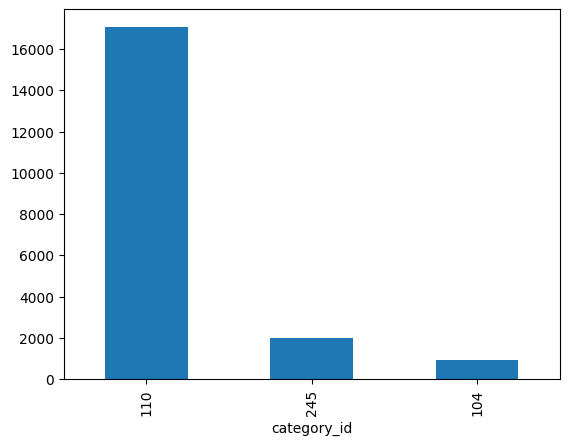

In [64]:
df['category_id'].value_counts().head(10).plot(kind='bar')

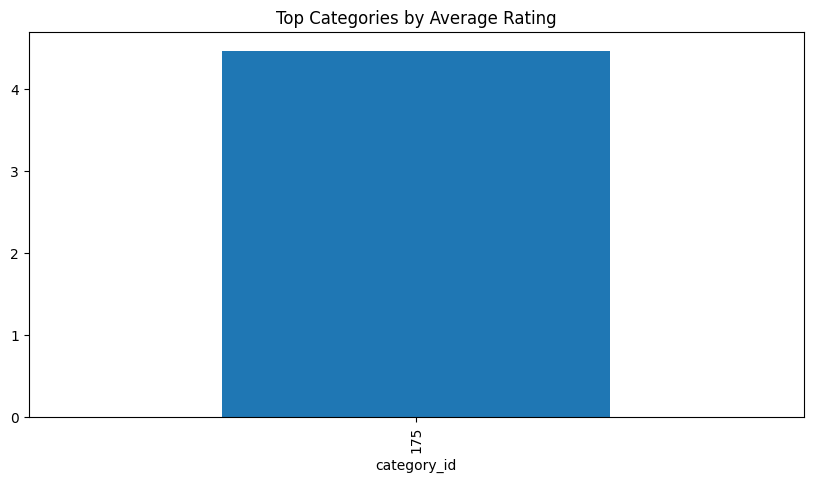

In [43]:
avg_rating = df.groupby('category_id')['stars'].mean().sort_values(ascending=False).head(10)

avg_rating.plot(kind='bar', figsize=(10,5))
plt.title("Top Categories by Average Rating")
plt.show()